# Problem Definintion
The problem at hand is to predict the credit risk of individuals based on their financial and personal information. The goal is to classify individuals into two categories: those who are likely to default on their loans (high risk) and those who are likely to repay their loans (low risk). This classification will help financial institutions make informed decisions about lending and managing credit risk.

In this dataset, the loan_status column is the target variable, which indicates whether an individual is a high risk (default) or low risk (repay). 
* '0' represents low risk (repay) and 
* '1' represents high risk (default). 

The features in the dataset include various financial and personal attributes of the individuals, such as their income, credit history, employment status, and more.

Since here, it is importnt to  predict both the true positive and true negatives accurately, we will be using the **F1 score** as our evaluation metric. The F1 score is the harmonic mean of precision and recall, which provides a balanced measure of both false positives and false negatives. This is particularly important in credit risk prediction, where both types of errors can have significant consequences for financial institutions.

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#%matplotlib inline

In [324]:
df = pd.read_csv('../data/raw/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Data Info

In [325]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [326]:
df.shape

(32581, 12)

### EDA

In [327]:
df.duplicated().sum()

# Since there are 165 duplicated rows fond, we will drop them.

df.drop_duplicates(inplace=True)

In [328]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [329]:
features = X.columns

In [330]:
categorical_cols = [feature for feature in features if X[feature].dtype == 'string']
numerical_cols = [feature for feature in features if X[feature].dtype != 'string']

categorical_cols, numerical_cols

(['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'],
 ['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'])

In [331]:
df[numerical_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,0.830000,30.000000


In [332]:
for feature in categorical_cols:
    print(f"{X[feature].value_counts()} \n")
    print(f"Value Count:{X[feature].nunique()} \n")
    print(f"-------------------------------------------------")

person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64 

Value Count:4 

-------------------------------------------------
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64 

Value Count:6 

-------------------------------------------------
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64 

Value Count:7 

-------------------------------------------------
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64 

Value Count:2 

-------------------------------------------------


### Data Visualization

<Axes: xlabel='loan_status', ylabel='count'>

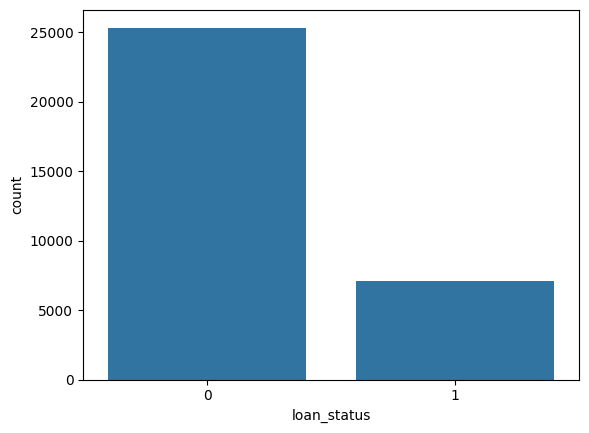

In [333]:
# EDA: Target Distribution
sns.countplot(data=df,x='loan_status')

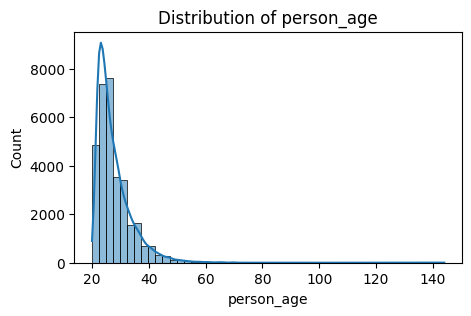

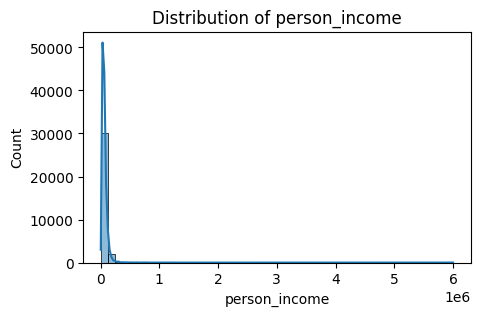

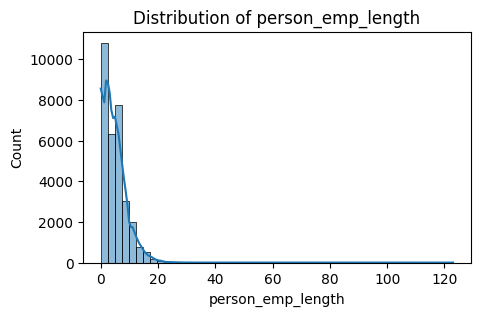

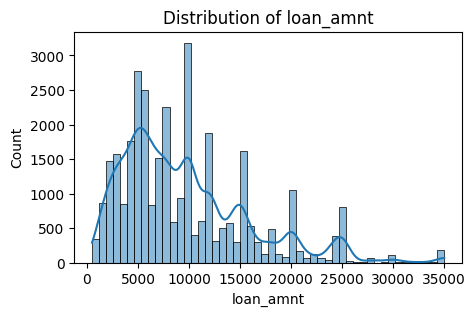

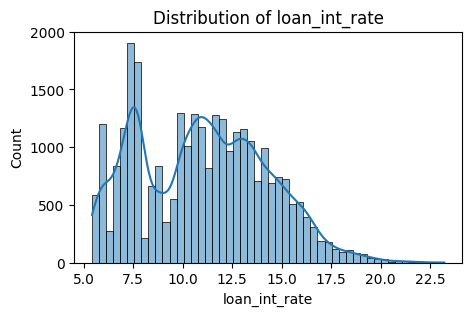

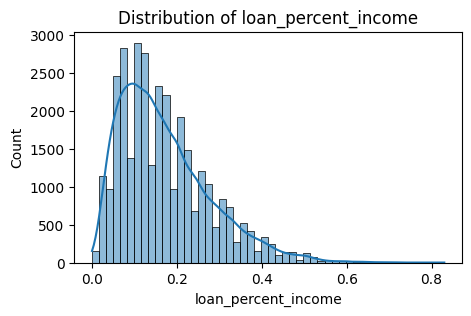

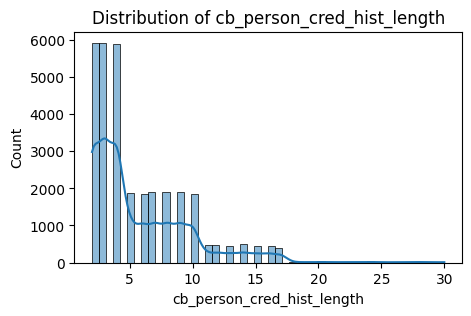

In [334]:
# EDA: Numerical Features Distribution
for feature in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(data=X,x=feature, bins=50,kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

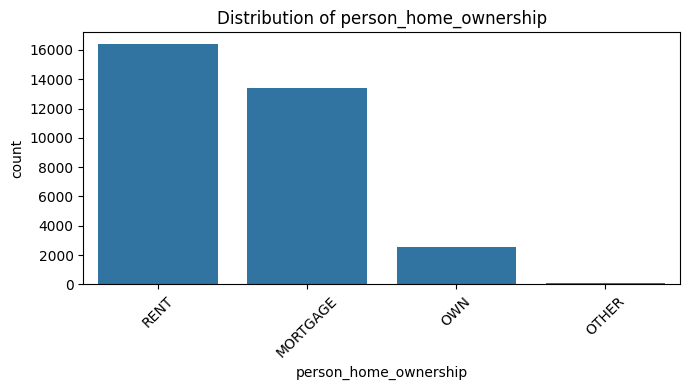

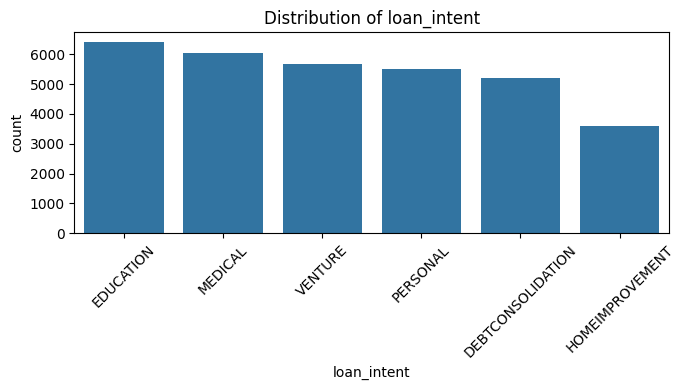

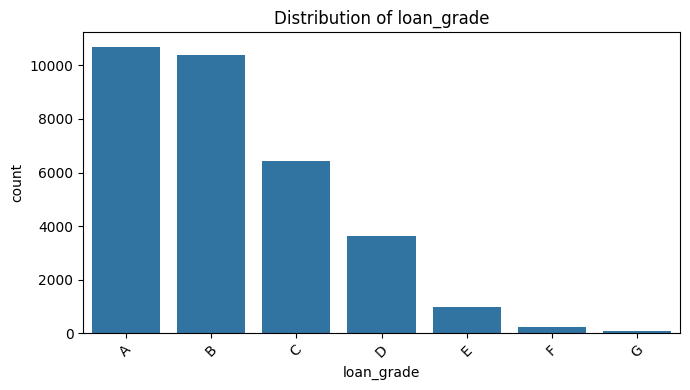

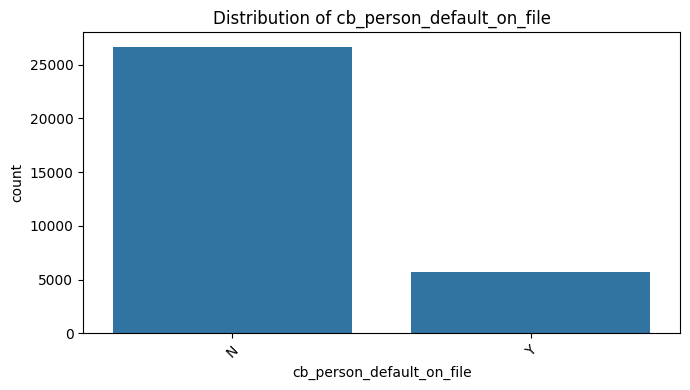

In [335]:
## EDA: Categorical Features Distribution
for feature in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=X,x=feature, order=X[feature].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {feature}")
    plt.tight_layout()
    plt.show()

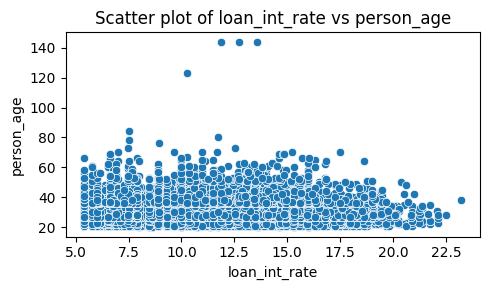

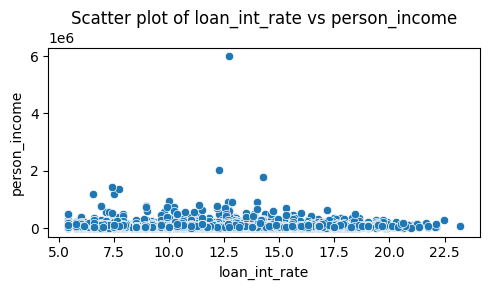

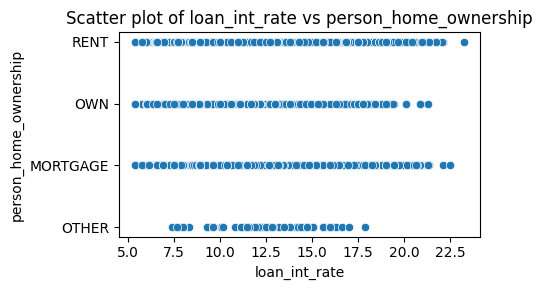

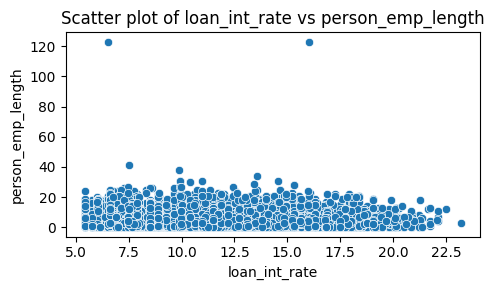

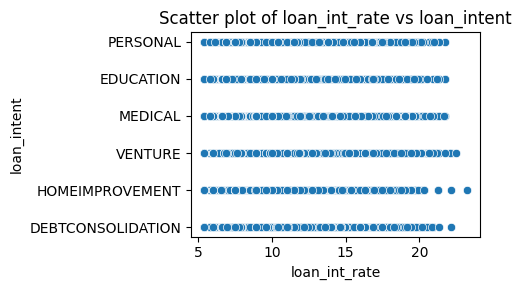

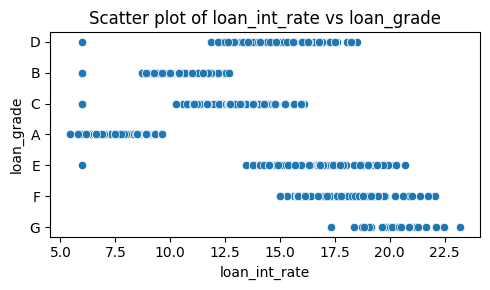

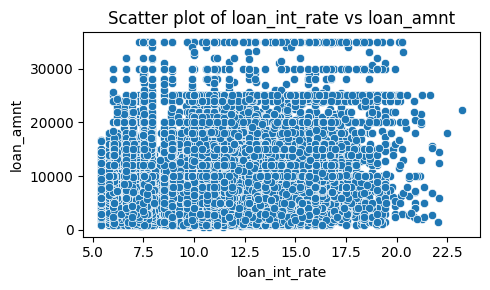

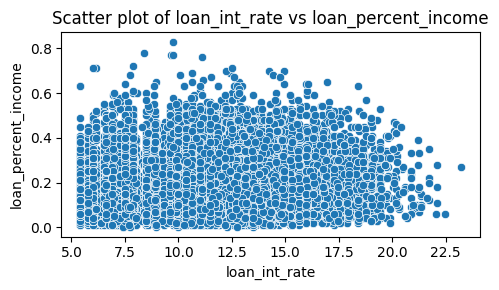

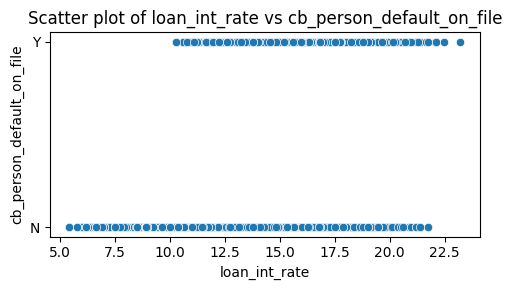

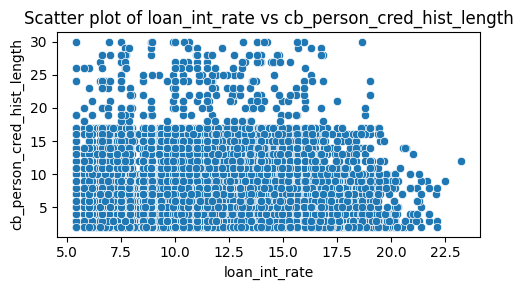

In [336]:
for feature in X.columns:
    if feature != 'loan_int_rate':
        plt.figure(figsize=(5, 3))
        sns.scatterplot(data=X, x='loan_int_rate', y=feature)
        plt.title(f"Scatter plot of loan_int_rate vs {feature}")
        plt.tight_layout()
        plt.show()

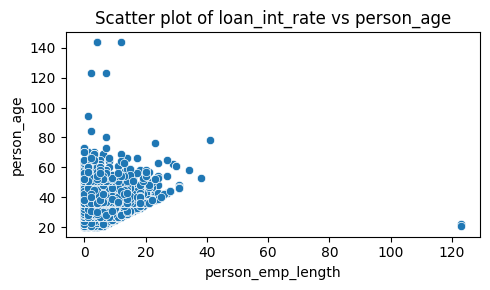

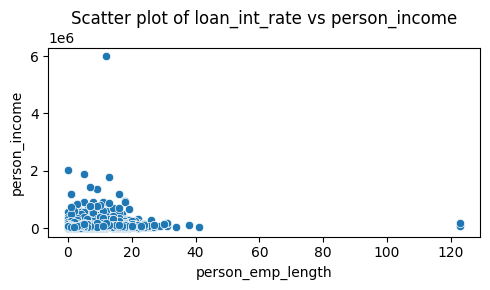

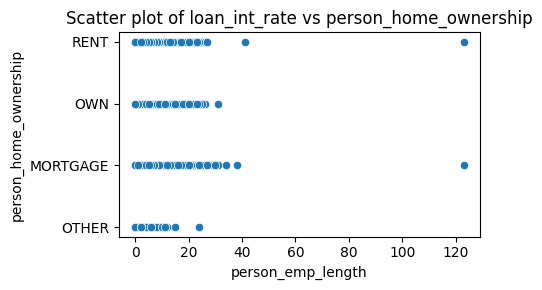

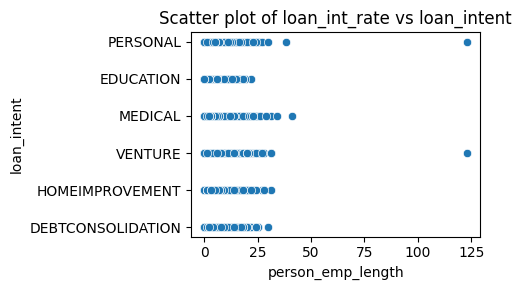

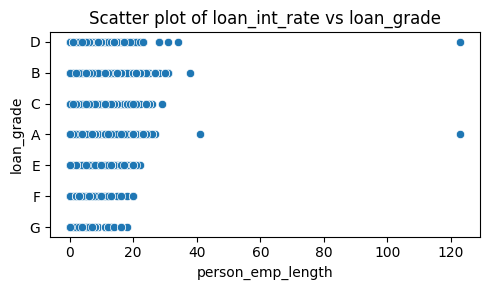

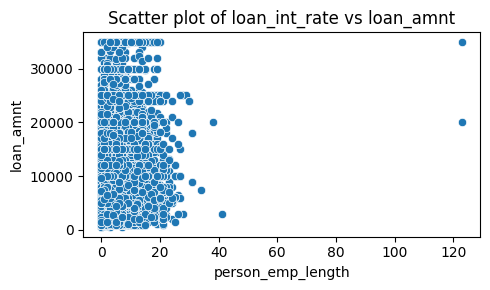

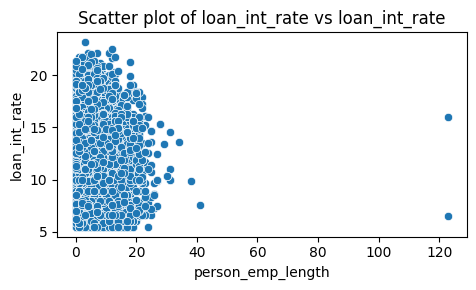

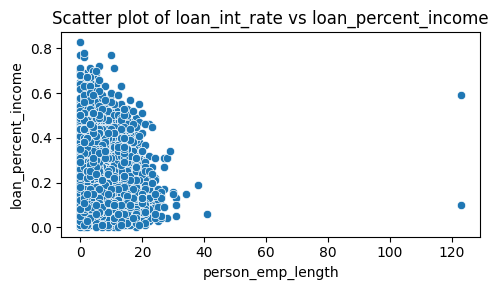

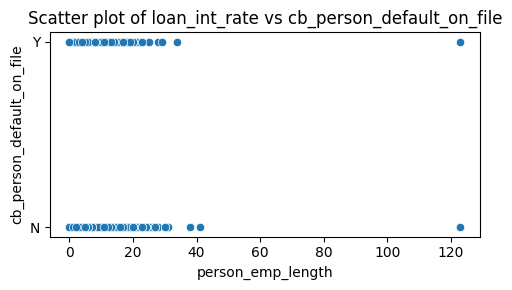

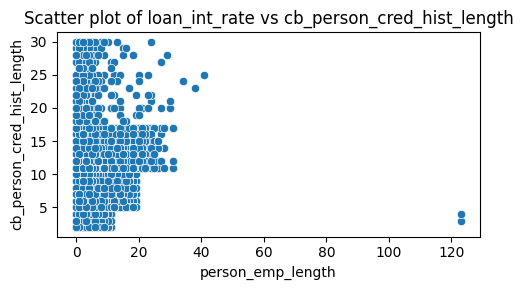

In [337]:
for feature in X.columns:
    if feature != 'person_emp_length':
        plt.figure(figsize=(5, 3))
        sns.scatterplot(data=X, x='person_emp_length', y=feature)
        plt.title(f"Scatter plot of loan_int_rate vs {feature}")
        plt.tight_layout()
        plt.show()

<Axes: >

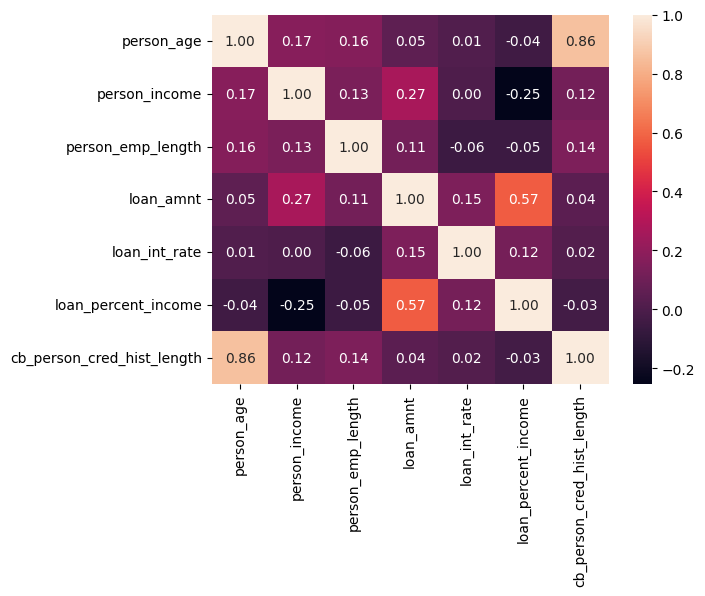

In [338]:
sns.heatmap(X[numerical_cols].corr(), annot=True, fmt='.2f')

## Data Preprocessing

In [339]:
# Checking the target vaariable distribution
df['loan_status'].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [340]:
print(X.columns)

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='str')


In [341]:
# Since the loan_int_rate is a numerical column and it has a strong correlation with the loan_grade column, 
# we will impute the missing values in loan_int_rate column with the median value of the respective loan_grade category.
for lg in X['loan_grade'].unique():
  X.loc[X['loan_grade']==lg, 'loan_int_rate']=X.loc[X['loan_grade']==lg]['loan_int_rate'].fillna(X.loc[X['loan_grade']==lg]['loan_int_rate'].median())

In [342]:
# person_emp_length has missing values but not strongly correlated with any other feature, 
# so we will impute the missing values in person_emp_length column with the median value of the entire column.
X['person_emp_length'] = X['person_emp_length'].fillna(X['person_emp_length'].median())

In [343]:
X.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [344]:
# No duplicated rows as we already dropped them, but we will check again to confirm.
X.duplicated().sum()

np.int64(0)

In [345]:
# Checking the datatypes
df.info()

<class 'pandas.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  str    
 3   person_emp_length           31529 non-null  float64
 4   loan_intent                 32416 non-null  str    
 5   loan_grade                  32416 non-null  str    
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               29321 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  str    
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.2 MB


In [346]:
# Encode the string datatypes

## To start with person_home_ownership column, I feel people witg own home have less risk than those who rent or have mortgage,
#  so we will encode them as follows:
print(X['person_home_ownership'].value_counts())

for value in list(df['person_home_ownership'].unique()):
    defaulter_ratio = len(df[(df['person_home_ownership'] == value) & (df['loan_status'] == 1)]) / len(df[df['person_home_ownership'] == value])
    print(f"\nDefault rate for {value}: {defaulter_ratio:.2%}")



person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

Default rate for RENT: 31.61%

Default rate for OWN: 7.49%

Default rate for MORTGAGE: 12.62%

Default rate for OTHER: 31.13%


In [347]:
X['person_home_ownership']=X['person_home_ownership'].map({'OWN':0, 'MORTGAGE':1, 'RENT':2, 'OTHER':3})

In [348]:
print(df['loan_intent'].value_counts())

for value in list(df['loan_intent'].unique()):
    defaulter_ratio = len(df[(df['loan_intent'] == value) & (df['loan_status'] == 1)]) / len(df[df['loan_intent'] == value])
    print(f"\nDefault rate for {value}: {defaulter_ratio:.2%}")




loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

Default rate for PERSONAL: 19.90%

Default rate for EDUCATION: 17.25%

Default rate for MEDICAL: 26.76%

Default rate for VENTURE: 14.85%

Default rate for HOMEIMPROVEMENT: 26.15%

Default rate for DEBTCONSOLIDATION: 28.68%


In [349]:
X.info()

<class 'pandas.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  int64  
 3   person_emp_length           32416 non-null  float64
 4   loan_intent                 32416 non-null  str    
 5   loan_grade                  32416 non-null  str    
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               32416 non-null  float64
 8   loan_percent_income         32416 non-null  float64
 9   cb_person_default_on_file   32416 non-null  str    
 10  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 3.0 MB


In [350]:
## Since the distribution of loan_intent categories is imbalanced, we will encode them using one-hot encoding.
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first',sparse_output=False)
X_encoded = ohe.fit_transform(X[['loan_intent']], )


In [351]:
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,2,123.0,PERSONAL,D,35000,16.02,0.59,Y,3
1,21,9600,0,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,1,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,2,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,2,8.0,MEDICAL,C,35000,14.27,0.55,Y,4


In [352]:
len(pd.DataFrame(X_encoded))
pd.DataFrame(X_encoded)

,0,1,2,3,4
0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
32411,0.0,0.0,0.0,1.0,0.0
32412,0.0,0.0,0.0,1.0,0.0
32413,0.0,1.0,0.0,0.0,0.0
32414,0.0,0.0,0.0,1.0,0.0


In [355]:
X=pd.concat([X, pd.DataFrame(X_encoded, columns=ohe.get_feature_names_out(['loan_intent']), index=X.index)], axis=1)

In [356]:
X.isnull().sum()

person_age                     0
person_income                  0
person_home_ownership          0
person_emp_length              0
loan_intent                    0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
dtype: int64

In [357]:
X['loan_intent_PERSONAL'].isnull().sum()

np.int64(0)

In [358]:
X['loan_grade'].value_counts()

loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

In [359]:
## We already chekcked the data earlier, the loan_grade is a direct flag of how risky the loan is, 
# where 'G' means highest risk and 'A' means lowest risk. Thus mappping them as 'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6
X['loan_grade'] = X['loan_grade'].map({'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6})

In [360]:
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,2,123.0,PERSONAL,3,35000,16.02,0.59,Y,3,0.0,0.0,0.0,1.0,0.0
1,21,9600,0,5.0,EDUCATION,1,1000,11.14,0.10,N,2,1.0,0.0,0.0,0.0,0.0
2,25,9600,1,1.0,MEDICAL,2,5500,12.87,0.57,N,3,0.0,0.0,1.0,0.0,0.0
3,23,65500,2,4.0,MEDICAL,2,35000,15.23,0.53,N,2,0.0,0.0,1.0,0.0,0.0
4,24,54400,2,8.0,MEDICAL,2,35000,14.27,0.55,Y,4,0.0,0.0,1.0,0.0,0.0


In [361]:
print(df['cb_person_default_on_file'].value_counts())

for value in list(df['cb_person_default_on_file'].unique()):
    defaulter_ratio = len(df[(df['cb_person_default_on_file'] == value) & (df['loan_status'] == 1)]) / len(df[df['cb_person_default_on_file'] == value])
    print(f"\nDefault rate for {value}: {defaulter_ratio:.2%}")

cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64

Default rate for Y: 37.87%

Default rate for N: 18.43%


In [362]:
## 'cb_person_default_on_file' lets map 'Y' to 1 and 'N' to 0, as those who have defaulted before are more likely to default again.
X['cb_person_default_on_file'] = X['cb_person_default_on_file'].map({'Y':1, 'N':0})

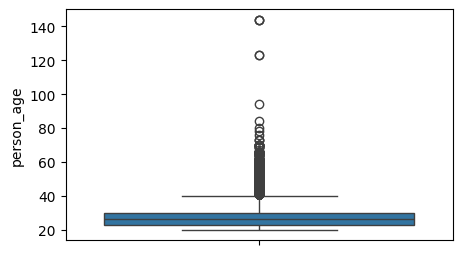

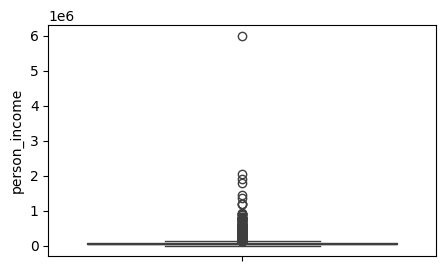

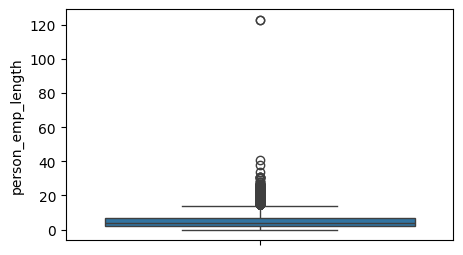

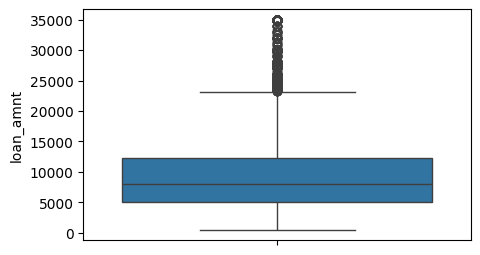

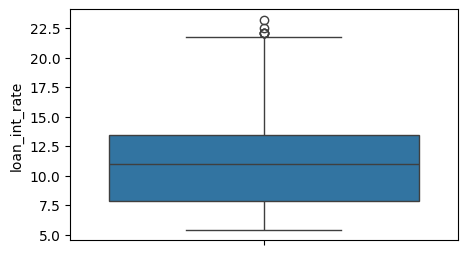

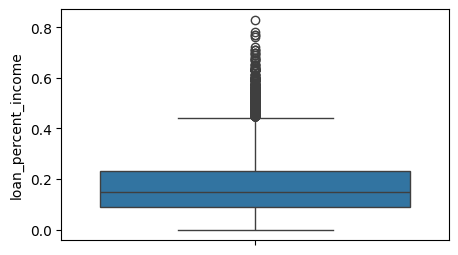

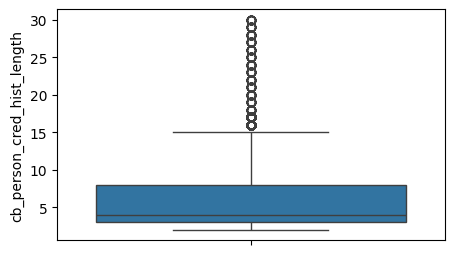

In [363]:
## Next we'll check for outlier in all the columns.
for feature in numerical_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=X, y=feature)
    plt.show()

In [ ]:
X['person_age']=X['person_age'].clip(upper=80)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,perosn_age


In [373]:
## Now we will check for outliers in person_income column, since it has a wide range of values, 
# we will check for values greater than 20 lakhs and then impute them with 99%ile value of the column.
X.loc[X['person_income']>2000000, 'person_income'] = X['person_income'].quantile(0.99)

In [ ]:
## Clipped the outlier to the upper range calculated using IQR method.
upper_range = X['person_emp_length'].quantile(0.75) + 1.5 * (X['person_emp_length'].quantile(0.75) - X['person_emp_length'].quantile(0.25))
upper_range

np.float64(14.5)

In [381]:
X['person_emp_length'] = X['person_emp_length'].clip(upper=upper_range)

In [382]:
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,perosn_age
0,22,59000,2,14.5,PERSONAL,3,35000,16.02,0.59,1,3,0.0,0.0,0.0,1.0,0.0,22
1,21,9600,0,5.0,EDUCATION,1,1000,11.14,0.10,0,2,1.0,0.0,0.0,0.0,0.0,21
2,25,9600,1,1.0,MEDICAL,2,5500,12.87,0.57,0,3,0.0,0.0,1.0,0.0,0.0,25
3,23,65500,2,4.0,MEDICAL,2,35000,15.23,0.53,0,2,0.0,0.0,1.0,0.0,0.0,23
4,24,54400,2,8.0,MEDICAL,2,35000,14.27,0.55,1,4,0.0,0.0,1.0,0.0,0.0,24


In [383]:
X = X.drop(['loan_intent','perosn_age'], axis=1)
X.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,2,14.5,3,35000,16.02,0.59,1,3,0.0,0.0,0.0,1.0,0.0
1,21,9600,0,5.0,1,1000,11.14,0.10,0,2,1.0,0.0,0.0,0.0,0.0
2,25,9600,1,1.0,2,5500,12.87,0.57,0,3,0.0,0.0,1.0,0.0,0.0
3,23,65500,2,4.0,2,35000,15.23,0.53,0,2,0.0,0.0,1.0,0.0,0.0
4,24,54400,2,8.0,2,35000,14.27,0.55,1,4,0.0,0.0,1.0,0.0,0.0


In [384]:
## Now all the Data Processing seems done, we 'll proceed to getting the scopr for the base model (Logistic Regression).

In [385]:
## To use Logistic Regression, we need to scale the numerical features, so we'll use StandardScaler for that.
## But before the we need to split the data into train and test sets, 
# so that we can fit the scaler only on the training data and then transform both train and test data.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

### Model Traning and Evaluation

In [424]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [431]:
def evaluate_model(y_pred, y_test):
    # print(f"Accuracy Score:{accuracy_score(y_test, y_pred):.2f}")
    print(f"F1 Score:{f1_score(y_test, y_pred):.2f}")
    print(f"ROC AUC Score:{roc_auc_score(y_test, y_pred):.2f}")
    print(f"Recall Score: {recall_score(y_test, y_pred):.2f}")
    print(f"Precision Score: {precision_score(y_test, y_pred):.2f}")
    # print("\nConfusion Matrix:")
    # print(confusion_matrix(y_test, y_pred))
    # print("\nClassification Report:")
    # print(classification_report(y_test, y_pred))

In [434]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
ab = AdaBoostClassifier()
svc = SVC()
knn = KNeighborsClassifier()
models = [lr,svc, knn, dt, rf, gb, ab]

def apply_model(models, X_train, y_train, X_test, y_test):
    for model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"*************************************************************\n")
        print(f"{model.__class__.__name__} Training data:\n")
        evaluate_model(y_pred, y_test)
        print(f"\n--------------------------------------------------------------\n")
        print(f"{model.__class__.__name__} Test data:\n")
        evaluate_model(y_pred, y_test)
        print(f"*************************************************************\n")


In [435]:
apply_model(models, X_train, y_train, X_test, y_test)

*************************************************************

LogisticRegression Training data:

F1 Score:0.59
ROC AUC Score:0.72
Recall Score: 0.49
Precision Score: 0.74

--------------------------------------------------------------

LogisticRegression Test data:

F1 Score:0.59
ROC AUC Score:0.72
Recall Score: 0.49
Precision Score: 0.74
*************************************************************

*************************************************************

SVC Training data:

F1 Score:0.75
ROC AUC Score:0.81
Recall Score: 0.62
Precision Score: 0.94

--------------------------------------------------------------

SVC Test data:

F1 Score:0.75
ROC AUC Score:0.81
Recall Score: 0.62
Precision Score: 0.94
*************************************************************

*************************************************************

KNeighborsClassifier Training data:

F1 Score:0.71
ROC AUC Score:0.79
Recall Score: 0.60
Precision Score: 0.87

---------------------------------------------

In [436]:
## The Random Forest Classifier seems to be performing the best among all the models, 
# with an F1 score of 0.82, an ROC AUC score of 0.85, and an accuracy score of 0.95 on the test data.

### Hyperparameter Tuning

In [437]:
rf_params = {
    'n_estimators': [50,100, 150,200, 500, 1000],
    'max_depth': [None, 4, 6, 8, 10, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rcv_models = {"Random Forest": [RandomForestClassifier(), rf_params]}

In [438]:
from sklearn.model_selection import RandomizedSearchCV

In [439]:
for i in range(len(rcv_models.keys())):
    model_name = list(rcv_models.keys())[i]
    model = rcv_models[model_name][0]
    params = rcv_models[model_name][1]
    
    print(f"Performing RandomizedSearchCV Search for {model_name}...")
    random_search_cv = RandomizedSearchCV(estimator=model, param_distributions=params, scoring='f1', cv=5, n_jobs=-1, verbose=2)
    random_search_cv.fit(X_train, y_train)
    
    print(f"Best parameters for {model_name}: {random_search_cv.best_params_}")
    # best_model = random_search_cv.best_estimator_
    
    # y_pred = best_model.predict(X_test)
    
    # print(f"Evaluation of {model_name} with best parameters:")
    # evaluate_model(y_pred, y_test)



Performing RandomizedSearchCV Search for Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Random Forest: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [440]:
rf_model = RandomForestClassifier(n_estimators=150, max_depth=None, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
evaluate_model(y_pred, y_test)

F1 Score:0.82
ROC AUC Score:0.85
Recall Score: 0.71
Precision Score: 0.97


In [441]:
## Get the importance of columns

loan_intent_VENTURE            0.012100
cb_person_default_on_file      0.012621
loan_intent_PERSONAL           0.013607
loan_intent_MEDICAL            0.015382
loan_intent_HOMEIMPROVEMENT    0.016776
loan_intent_EDUCATION          0.016846
cb_person_cred_hist_length     0.029700
person_age                     0.040944
person_emp_length              0.052274
loan_amnt                      0.071757
person_home_ownership          0.104540
loan_grade                     0.114046
loan_int_rate                  0.117836
person_income                  0.148726
loan_percent_income            0.232845
dtype: float64


<Axes: >

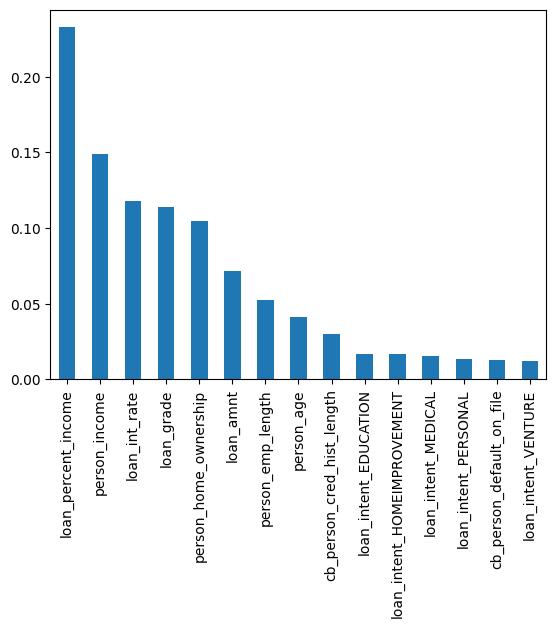

In [444]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importances.sort_values())
importances.sort_values(ascending=False).plot(kind='bar')

In [ ]:
## 